# Audio Quality Analysis

In [ ]:
import os
import json
import torch
import numpy as np
import pandas as pd


pd.set_option('display.float_format', '{:.6f}'.format)

def load_dataset(path):
    """
    Load dataset from the specified path.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at {path}")
    
    def inverse_split_dict(split_dict):
        # Add split column to dvi2Torch based on dvi2_torch["split"]
        clique_to_split = {}
        for split_name, sub_dict in split_dict.items():
            for clique in sub_dict.keys():
                clique_to_split[clique] = split_name
        return clique_to_split

    if path.endswith(".json"):
        with open(path, "r") as f:
            meta = json.load(f)
    elif path.endswith(".pt"):
        meta = torch.load(path, weights_only=False)
    if isinstance(meta, dict) and "info" in meta:
        info =  meta["info"]
        split = meta["split"]
    else:
        info, split = meta

    df = pd.DataFrame.from_dict(info, orient="index")
           
    clique2split = inverse_split_dict(split)
    df["split"] = df["clique"].map(clique2split)
    
    if "youtube_id" not in df.columns:
        df["youtube_id"] = df.filename.apply(lambda x: x.split("/")[-1].split(".")[0])
    
    df["dvi"] = ~df.apply(lambda x: x.youtube_id in x.version, axis=1)
    
    return df, meta    

df, _ = load_dataset("data/final_se/divers_se_quality2.pt")


In [32]:
q = 0.25
n = 3

df.columns

Index(['id', 'clique', 'version', 'artist', 'title', 'filename', 'youtube_id',
       'dvi', 'track_writer_names', 'release_artist_names', 'release_genres',
       'release_styles', 'country', 'labels', 'formats', 'released',
       'yt_title', 'yt_description', 'yt_tags', 'yt_categories', 'yt_channel',
       'yt_upload_date', 'yt_view_count', 'tempo', 'tags_yt_title',
       'cues_yt_title', 'tags_yt_description', 'cues_yt_description',
       'tags_yt_tags', 'cues_yt_tags', 'hash', 'duration',
       'music_segment_inds', 'split', 'spectral_flatness_mean',
       'spectral_flatness_std', 'spectral_flatness_p90',
       'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_rolloff_p90',
       'hf_ratio_mean', 'hf_ratio_std', 'hf_ratio_p90', 'zcr_mean', 'zcr_std',
       'zcr_p90', 'rms_mean', 'rms_std', 'rms_p90', 'dynamic_range',
       'noise_floor', 'signal_level', 'snr_proxy'],
      dtype='object')

## SNR Proxy

Low snr --> noisier.

In [7]:
df.snr_proxy.describe()


count    1102311.000000
mean        6855.302435
std       410246.518871
min            1.014424
25%            3.554904
50%            5.186841
75%            8.061462
max     56905604.000000
Name: snr_proxy, dtype: float64

In [34]:
# noisy
df[df["snr_proxy"] <= df["snr_proxy"].quantile(q)].sample(n)


,id,clique,version,artist,title,filename,youtube_id,dvi,track_writer_names,release_artist_names,...,zcr_mean,zcr_std,zcr_p90,rms_mean,rms_std,rms_p90,dynamic_range,noise_floor,signal_level,snr_proxy
C-0074526:ntC7302e0D0,418694,C-0074526,ntC7302e0D0,None,None,nt/ntC7302e0D0.mp3,ntC7302e0D0,False,NaN,NaN,...,0.171165,0.036872,0.219238,0.197812,0.025070,0.221719,30.313007,0.148607,0.234495,1.577947
C-0081507:6m5B6c8UJG8,890563,C-0081507,6m5B6c8UJG8,None,None,6m/6m5B6c8UJG8.mp3,6m5B6c8UJG8,False,NaN,NaN,...,0.168960,0.030123,0.203613,0.074429,0.027030,0.107099,31.848808,0.037471,0.128637,3.432944
C-0084809:l8wcMn3skE8,273512,C-0084809,l8wcMn3skE8,None,None,l8/l8wcMn3skE8.mp3,l8wcMn3skE8,False,NaN,NaN,...,0.075672,0.038040,0.120117,0.205617,0.067684,0.297482,31.916561,0.091036,0.321348,3.529904


In [35]:
# clean
df[df["snr_proxy"] >= df["snr_proxy"].quantile(1 - q)].sample(n)

,id,clique,version,artist,title,filename,youtube_id,dvi,track_writer_names,release_artist_names,...,zcr_mean,zcr_std,zcr_p90,rms_mean,rms_std,rms_p90,dynamic_range,noise_floor,signal_level,snr_proxy
C-0203774:vq_6Q6JjKT8,832294,C-0203774,vq_6Q6JjKT8,None,None,vq/vq_6Q6JjKT8.mp3,vq_6Q6JjKT8,False,NaN,NaN,...,0.079058,0.050481,0.122070,0.133292,0.077489,0.232991,51.923912,0.003304,0.264071,79.928116
C-0107518:o2L16yGC1bQ,777952,C-0107518,o2L16yGC1bQ,None,None,o2/o2L16yGC1bQ.mp3,o2L16yGC1bQ,False,NaN,NaN,...,0.105529,0.063464,0.193359,0.133203,0.065981,0.213817,36.358612,0.027620,0.255786,9.260932
C-0085471:zGcV5pVI_r0,692730,C-0085471,zGcV5pVI_r0,None,None,zG/zGcV5pVI_r0.mp3,zGcV5pVI_r0,False,NaN,NaN,...,0.142107,0.071372,0.236816,0.066199,0.029438,0.101025,35.639828,0.013848,0.115600,8.347750


## Noise Floor

Higher noise floor --> noisier signal.

In [ ]:
df.noise_floor.describe()

count   1102311.000000
mean          0.047540
std           0.038770
min           0.000000
25%           0.020952
50%           0.037680
75%           0.063130
max           0.793144
Name: noise_floor, dtype: float64

In [22]:
df.loc[df.noise_floor.quantile(0.75) > df.noise_floor].sample(n=3)

,id,clique,version,artist,title,filename,youtube_id,dvi,track_writer_names,release_artist_names,...,zcr_mean,zcr_std,zcr_p90,rms_mean,rms_std,rms_p90,dynamic_range,noise_floor,signal_level,snr_proxy
C-0184933:C1og1BsnB5Y,405650,C-0184933,C1og1BsnB5Y,None,None,C1/C1og1BsnB5Y.mp3,C1og1BsnB5Y,False,NaN,NaN,...,0.140220,0.093281,0.256348,0.062339,0.084328,0.197678,68.732269,0.000026,0.221333,8387.790039
C-0097022:ImA9TtrDUts,1212440,C-0097022,ImA9TtrDUts,None,None,Im/ImA9TtrDUts.mp3,ImA9TtrDUts,False,NaN,NaN,...,0.153941,0.085798,0.270996,0.127393,0.084414,0.268140,49.863762,0.016536,0.303009,18.324326
C-0270468:1Bg4QfeEoNk,882501,C-0270468,1Bg4QfeEoNk,None,None,1B/1Bg4QfeEoNk.mp3,1Bg4QfeEoNk,False,NaN,NaN,...,0.199033,0.050453,0.258789,0.109670,0.039234,0.156808,34.646545,0.038886,0.168602,4.335793


## Dynamic Range
Proxy: higher --> higher audio quality.

**Note: audio duration is not considered!**


In [29]:
import pandas as pd

pd.set_option('display.float_format', '{:.6f}'.format)

df.dynamic_range.describe()

count   1102311.000000
mean         34.982791
std           4.341977
min           0.711711
25%          32.493626
50%          34.041920
75%          36.157259
max          77.604431
Name: dynamic_range, dtype: float64

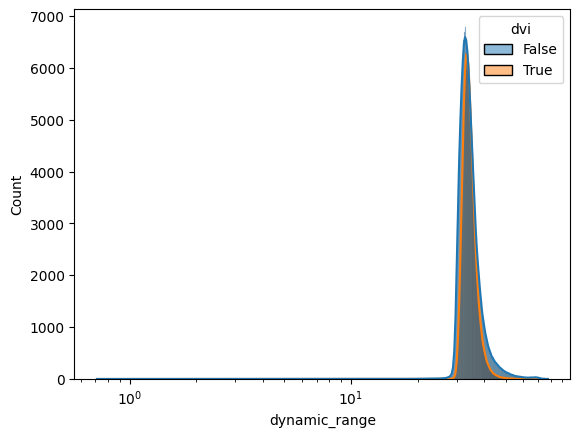

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df, x="dynamic_range", kde=True, hue="dvi")
plt.xscale("log")
plt.show()


In [32]:
df.loc[df.dynamic_range < 10]

,id,clique,version,artist,title,filename,youtube_id,dvi,track_writer_names,release_artist_names,...,zcr_mean,zcr_std,zcr_p90,rms_mean,rms_std,rms_p90,dynamic_range,noise_floor,signal_level,snr_proxy
C-0244856:5RonpPUjv88,1005303,C-0244856,5RonpPUjv88,None,None,5R/5RonpPUjv88.mp3,5RonpPUjv88,False,NaN,NaN,...,0.000098,0.003338,0.000000,0.469946,0.019399,0.501426,4.410310,0.447367,0.510137,1.140310
C-0088153:TbmR3aKl870,302028,C-0088153,TbmR3aKl870,None,None,Tb/TbmR3aKl870.mp3,TbmR3aKl870,False,NaN,NaN,...,0.000554,0.002871,0.001953,0.123915,0.002534,0.126209,7.477485,0.120661,0.127153,1.053801
C-0199398:aXKvSfyMcrE,562519,C-0199398,aXKvSfyMcrE,None,None,aX/aXKvSfyMcrE.mp3,aXKvSfyMcrE,False,NaN,NaN,...,0.000203,0.003925,0.000000,0.129235,0.002668,0.129839,0.900000,0.127521,0.130007,1.019492
C-0199398:V8OPPGA-8sM,562515,C-0199398,V8OPPGA-8sM,None,None,V8/V8OPPGA-8sM.mp3,V8OPPGA-8sM,False,NaN,NaN,...,0.000191,0.003939,0.000000,0.490853,0.013031,0.500076,6.300188,0.476589,0.503204,1.055846
C-0333864:6kmpCbrRwGI,129553,C-0333864,6kmpCbrRwGI,None,None,6k/6kmpCbrRwGI.mp3,6kmpCbrRwGI,False,NaN,NaN,...,0.000634,0.011212,0.000000,0.442107,0.014501,0.448494,4.487571,0.427294,0.450577,1.054491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C-0062182:hiWNF4EzxTo,856645,C-0062182,hiWNF4EzxTo,None,None,hi/hiWNF4EzxTo.mp3,hiWNF4EzxTo,False,NaN,NaN,...,0.000283,0.008729,0.000000,0.085442,0.002580,0.087117,6.921938,0.082999,0.088234,1.063072
C-0118298:MlFGoxtKHFM,1432402,C-0118298,MlFGoxtKHFM,None,None,Ml/MlFGoxtKHFM.mp3,MlFGoxtKHFM,False,NaN,NaN,...,0.003690,0.022921,0.000000,0.340969,0.055088,0.354609,3.946953,0.245400,0.357092,1.455143
C-0224774:vHBECHDAMwM,730578,C-0224774,vHBECHDAMwM,None,None,vH/vHBECHDAMwM.mp3,vHBECHDAMwM,False,NaN,NaN,...,0.087117,0.155567,0.394043,0.000123,0.001016,0.000010,7.982910,0.000000,0.001226,122637.007812
C-0133295:zTbiwh-Qf2c,1418424,C-0133295,zTbiwh-Qf2c,None,None,zT/zTbiwh-Qf2c.mp3,zTbiwh-Qf2c,False,NaN,NaN,...,0.000479,0.005543,0.000000,0.479060,0.012217,0.488831,4.024755,0.467364,0.492551,1.053892


## Spectral

Proxy: Higher flatness --> noisier audio.



In [24]:
df.spectral_flatness_mean.describe()



count   1102311.000000
mean          0.000654
std           0.006487
min           0.000000
25%           0.000138
50%           0.000254
75%           0.000430
max           0.946957
Name: spectral_flatness_mean, dtype: float64

In [27]:
df.loc[df.spectral_flatness_mean > df.spectral_flatness_mean.quantile(0.75)].sample(n=3)


,id,clique,version,artist,title,filename,youtube_id,dvi,track_writer_names,release_artist_names,...,zcr_mean,zcr_std,zcr_p90,rms_mean,rms_std,rms_p90,dynamic_range,noise_floor,signal_level,snr_proxy
C-0133841:yqL8qEygr5o,763712,C-0133841,yqL8qEygr5o,None,None,yq/yqL8qEygr5o.mp3,yqL8qEygr5o,False,NaN,NaN,...,0.146661,0.070885,0.243652,0.143641,0.038926,0.184234,33.689743,0.059489,0.201260,3.383156
C-0263667:WFRxO1cmm0E,1172225,C-0263667,WFRxO1cmm0E,None,None,WF/WFRxO1cmm0E.mp3,WFRxO1cmm0E,False,NaN,NaN,...,0.197226,0.044942,0.258789,0.107576,0.017662,0.128164,30.585533,0.074865,0.137940,1.842505
C-0199729:UhxvTyQHN5w,1226014,C-0199729,UhxvTyQHN5w,None,None,Uh/UhxvTyQHN5w.mp3,UhxvTyQHN5w,False,NaN,NaN,...,0.160546,0.136093,0.389551,0.057705,0.055457,0.134571,66.494759,0.000245,0.168733,688.005249


In [14]:
df.spectral_rolloff.describe()


count   1102311.000000
mean       2758.172295
std         707.242998
min          15.121900
25%        2286.750100
50%        2808.784100
75%        3276.107900
max        5475.164200
Name: spectral_rolloff, dtype: float64

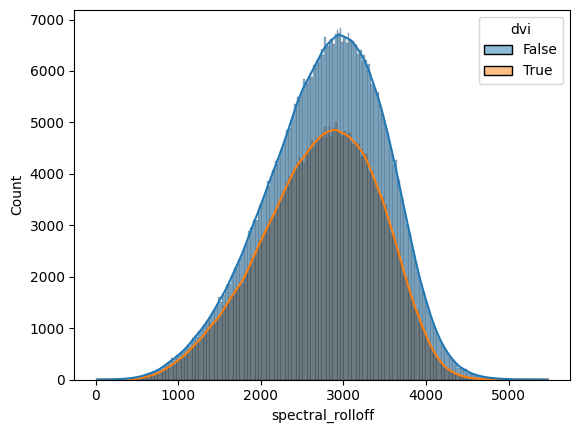

In [18]:
sns.histplot(df, x="spectral_rolloff", kde=True, hue="dvi")
#plt.xscale("log")
plt.show()


## High Frequency Ratio

Higher --> noiser.

In [31]:
df.hf_ratio_mean.describe()

count   1102311.000000
mean          0.083132
std           0.050944
min           0.000019
25%           0.047572
50%           0.075457
75%           0.110031
max           4.043322
Name: hf_ratio_mean, dtype: float64

## RMS

In [ ]:
'rms_mean', 'rms_std'

Index(['id', 'clique', 'version', 'artist', 'title', 'filename', 'youtube_id',
       'dvi', 'track_writer_names', 'release_artist_names', 'release_genres',
       'release_styles', 'country', 'labels', 'formats', 'released',
       'yt_title', 'yt_description', 'yt_tags', 'yt_categories', 'yt_channel',
       'yt_upload_date', 'yt_view_count', 'tempo', 'tags_yt_title',
       'cues_yt_title', 'tags_yt_description', 'cues_yt_description',
       'tags_yt_tags', 'cues_yt_tags', 'hash', 'duration',
       'music_segment_inds', 'split', 'rms_mean', 'rms_std',
       'dynamic_range_db', 'spectral_flatness', 'spectral_rolloff', 'hf_ratio',
       'zcr_mean', 'onset_density'],
      dtype='object')

## Combination

In [ ]:
difficulty =
    (-snr_proxy) +
    spectral_flatness_mean +
    (1 / (dynamic_range + 1e-6))
    